# Quantum Orthogonal Neural Network Training on COCO Dataset

This notebook demonstrates training a quantum orthogonal neural network with statistical pruning on the COCO dataset. The model uses a hybrid quantum-classical architecture with scheduled gradient pruning.

In [39]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silence INFO and WARNING messages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import pennylane as qml
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Import our custom model and utilities
import sys
sys.path.append('../src')
from models.orthogonal_nn import HybridModel
from utils.rbs_gate import *
from utils.pruning import ScheduledGradientPruning

## 1. Data Loading and Preprocessing

First, we'll load and preprocess the COCO dataset. We'll focus on a subset of the dataset for demonstration purposes.

In [46]:
def load_coco_data(data_dir='../data/test2017', 
                   annotation_file='../data/annotations/image_info_test2017.json',
                   img_size=(32, 32)):
    """
    Load COCO dataset images using a JSON file that connects images to categories via the license field.
    Here we assume that each image's "license" field is a category id and that the corresponding
    category's "supercategory" is used as the annotation (label).

    Args:
        data_dir (str): Directory containing image files.
        annotation_file (str): Path to the JSON file with image info.
        img_size (tuple): Target size (height, width) for image resizing.
    
    Returns:
        images (np.array): Array of preprocessed images.
        labels (np.array): Array of corresponding binary labels (float 0.0 or 1.0).
    """
    # Load the JSON file
    with open(annotation_file, 'r') as f:
        coco_data = json.load(f)
    print("Number of images in annotation:", len(coco_data.get('images', [])))
    print("Number of categories in annotation:", len(coco_data.get('categories', [])))

    # Extract image info and categories
    images_info = coco_data.get('images', [])
    categories = coco_data.get('categories', [])
    
    # Create a mapping from category id to its supercategory (annotation)
    # Note: This mapping is built from the "categories" field.
    cat_map = {cat['id']: cat['supercategory'] for cat in categories}
    
    images = []
    labels = []
    
    # Define your binary mapping here.
    binary_map = {
        "person": 0.0,
        "vehicle": 1.0
    }
    
    # Process each image in the JSON
    for img_info in tqdm(images_info, desc='Loading images'):
        file_name = img_info.get('file_name')
        license_id = img_info.get('license')
        
        # Use license_id to get the label from cat_map
        label_str = cat_map.get(license_id)
        if label_str is None:
            # Skip image if no corresponding category found
            continue
        
        # Convert string label to binary float.
        # If the label is not in binary_map, skip the image.
        if label_str not in binary_map:
            continue
        label = binary_map[label_str]
        
        img_path = os.path.join(data_dir, file_name)
        if not os.path.exists(img_path):
            print(f"Image file not found: {img_path}")
            continue
        
        try:
            # Load and preprocess the image
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = img_array / 255.0  # Normalize to [0,1]
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"Error processing image {img_path}: {e}")
            continue

    images = np.array(images)
    labels = np.array(labels, dtype=np.float32)
    print(f"Successfully loaded {len(images)} images with labels.")
    return images, labels

# Load data
X, y = load_coco_data()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create TensorFlow datasets
batch_size = 16  # Smaller batch size for quantum computation
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

Number of images in annotation: 40670
Number of categories in annotation: 80


Loading images:   0%|          | 16/40670 [00:00<04:28, 151.39it/s]

Loading images: 100%|██████████| 40670/40670 [04:39<00:00, 145.65it/s]


Successfully loaded 40670 images with labels.


## 2. Model Configuration

Configure the quantum orthogonal neural network with statistical pruning.

In [47]:
# Model parameters
random_seed = 42
algorithm = 'pruning'
algorithm_params = {
    'accumulate_window': 100,  # Number of steps to accumulate gradients
    'prune_window': 20,       # Number of steps between pruning operations
    'prune_ratio': 0.1,        # Ratio of weights to prune
    'schedule': 'linear'       # Pruning schedule (linear, exponential, or step)
}

# Create and compile the model
model = HybridModel(
    random=random_seed,
    algorithm=algorithm,
    algorithm_params=algorithm_params,
    wires=6
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 3. Training Loop

Train the model with custom callbacks to monitor the pruning process.

In [48]:
class PruningCallback(tf.keras.callbacks.Callback):
    def __init__(self, model):
        super(PruningCallback, self).__init__()
        self.model = model
        self.pruning_history = []
    
    def on_epoch_end(self, epoch, logs=None):
        if hasattr(self.model, 'algorithm'):
            pruning_stats = self.model.algorithm.get_pruning_stats()
            self.pruning_history.append(pruning_stats)
            print(f"Epoch {epoch + 1}: Pruning ratio = {pruning_stats['current_ratio']:.3f}")

# Training parameters
epochs = 100
callbacks = [
    PruningCallback(model),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=test_dataset,
    callbacks=callbacks
)

Epoch 1/100
2034/2034 [==============================] - 259s 121ms/step - loss: 0.5788 - accuracy: 0.7352 - val_loss: 0.5789 - val_accuracy: 0.7351
Epoch 2/100
Updated prune_ratio to 1
2034/2034 [==============================] - 242s 119ms/step - loss: 0.5780 - accuracy: 0.7353 - val_loss: 0.5786 - val_accuracy: 0.7351
Epoch 3/100
2034/2034 [==============================] - 243s 119ms/step - loss: 0.5781 - accuracy: 0.7353 - val_loss: 0.5786 - val_accuracy: 0.7351
Epoch 4/100
2034/2034 [==============================] - 242s 119ms/step - loss: 0.5780 - accuracy: 0.7353 - val_loss: 0.5786 - val_accuracy: 0.7351
Epoch 5/100
2034/2034 [==============================] - 244s 120ms/step - loss: 0.5780 - accuracy: 0.7353 - val_loss: 0.5787 - val_accuracy: 0.7351
Epoch 6/100
2034/2034 [==============================] - 249s 122ms/step - loss: 0.5776 - accuracy: 0.7353 - val_loss: 0.5786 - val_accuracy: 0.7351
Epoch 7/100
2034/2034 [==============================] - 282s 139ms/step - loss: 

## 4. Visualization and Analysis

Plot the training history and pruning statistics.

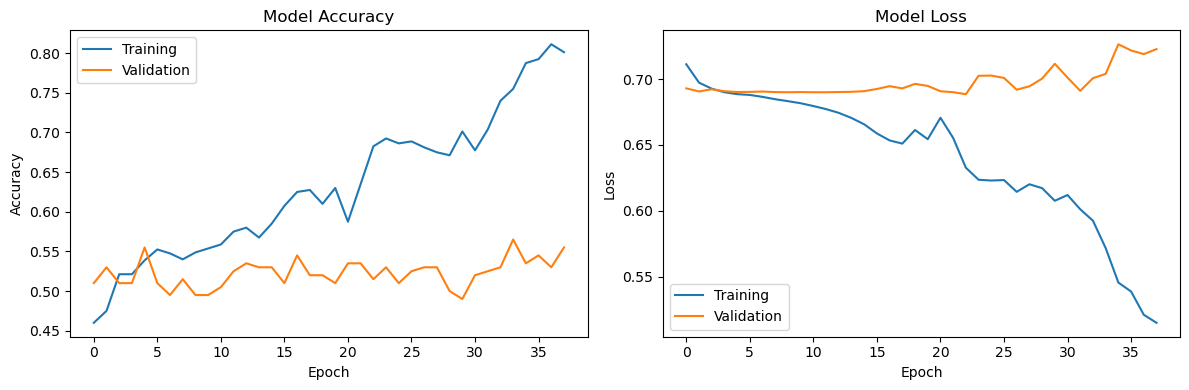

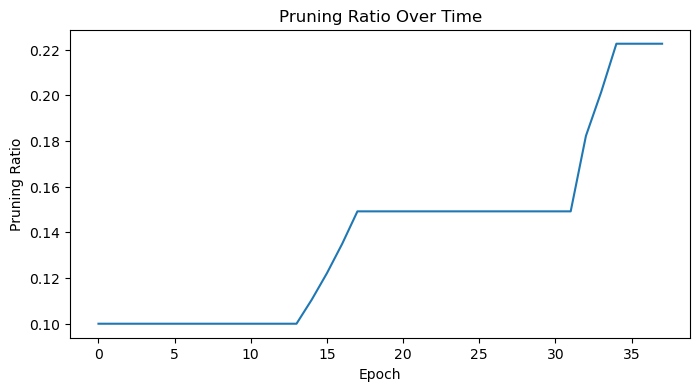

In [7]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def plot_pruning_history(callback):
    pruning_ratios = [stats['current_ratio'] for stats in callback.pruning_history]
    plt.figure(figsize=(8, 4))
    plt.plot(pruning_ratios)
    plt.title('Pruning Ratio Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Pruning Ratio')
    plt.show()

# Plot training history
plot_training_history(history)

# Plot pruning history
plot_pruning_history(callbacks[0])

## 5. Model Evaluation

Evaluate the model's performance on the test set.

In [6]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest accuracy: {test_accuracy:.4f}")

# Get final pruning statistics
final_stats = callbacks[0].pruning_history[-1]
print(f"\nFinal pruning ratio: {final_stats['current_ratio']:.3f}")
print(f"Number of pruned weights: {final_stats['num_pruned']}")
print(f"Total weights: {final_stats['total_weights']}")

2/2 [==============================] - 0s 84ms/step - loss: 0.6885 - accuracy: 0.5150

Test accuracy: 0.5150

Final pruning ratio: 0.223
Number of pruned weights: 3
Total weights: 15
